In [20]:
import pickle
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

plt.rcParams['text.usetex'] = False

In [ ]:
# Open file in read-binary mode
with open('data/samples/verification_test_simple_path.pickle', 'rb') as file_path:
    # Load the pickled data
    test_simple_path = pickle.load(file_path)

with open('data/samples/verification_test_star_graph.pickle', 'rb') as file_star:
    # Load the pickled data
    test_star_graph = pickle.load(file_star)

Plottting the probability $Pr(I_v < \infty| D_{obs})$ as it accumulates.

In [3]:
def cummulative_probabilities(node, tree_list):
    prob = []
    counting = 0
    N = 0

    for tree in tree_list:
        N += 1
        if node in tree:counting += 1
        prob.append(counting/N)

    return prob

We start with the simple path example:

In [7]:
it_50000_simple_path_node_2 = cummulative_probabilities(2, test_simple_path[2][1:])
it_50000_simple_path_node_3 = cummulative_probabilities(3, test_simple_path[2][1:])

Ploting the probability as it accumulates as the number of iterations increases up to $n = 50000$.

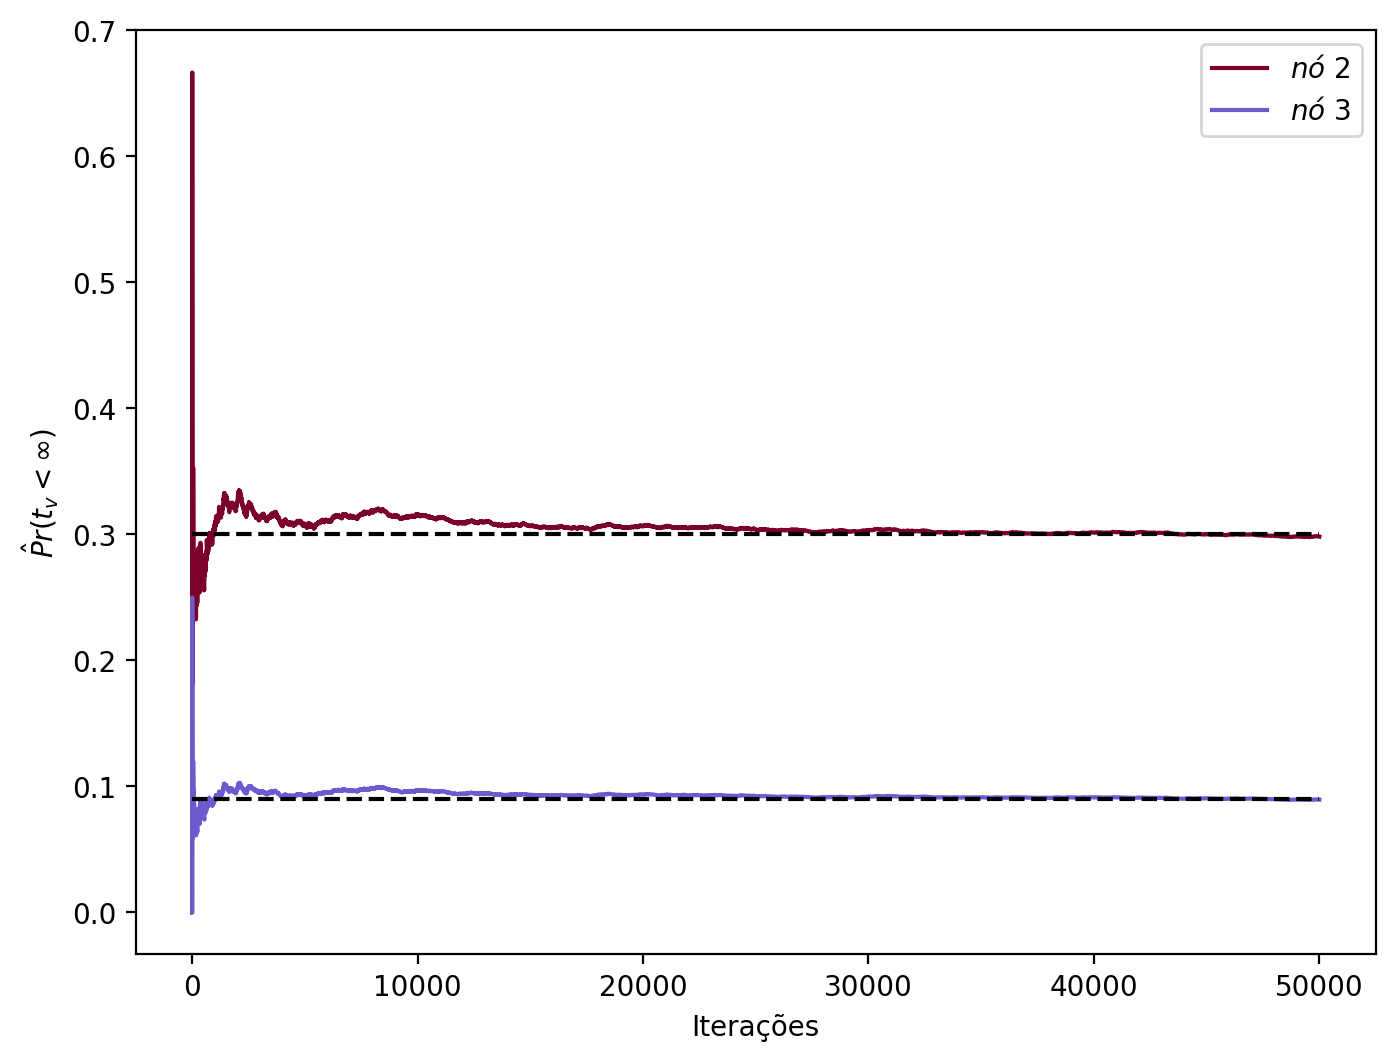

In [ ]:
figure(figsize=(8, 6), dpi=200)

plt.plot(it_50000_simple_path_node_2, label=r'$node ~ 2$', color='xkcd:bordeaux')
plt.plot(it_50000_simple_path_node_3, label=r'$node ~ 3$', color='xkcd:light indigo')
plt.hlines(y=[0.09, 0.3], xmin=0, xmax=50000, colors=['black', 'black'], linestyles=['-', '--'])
plt.ylabel(r'$\hat{P}r(I_v < \infty | D_{obs})$')
plt.xlabel('Iterations')
plt.legend()
plt.show()

Now, we produce a convergence image for the star graph case

In [28]:
star_node_1 = cummulative_probabilities(1, test_star_graph[2][1:])
star_node_3 = cummulative_probabilities(3, test_star_graph[2][1:])

Producing the plot:

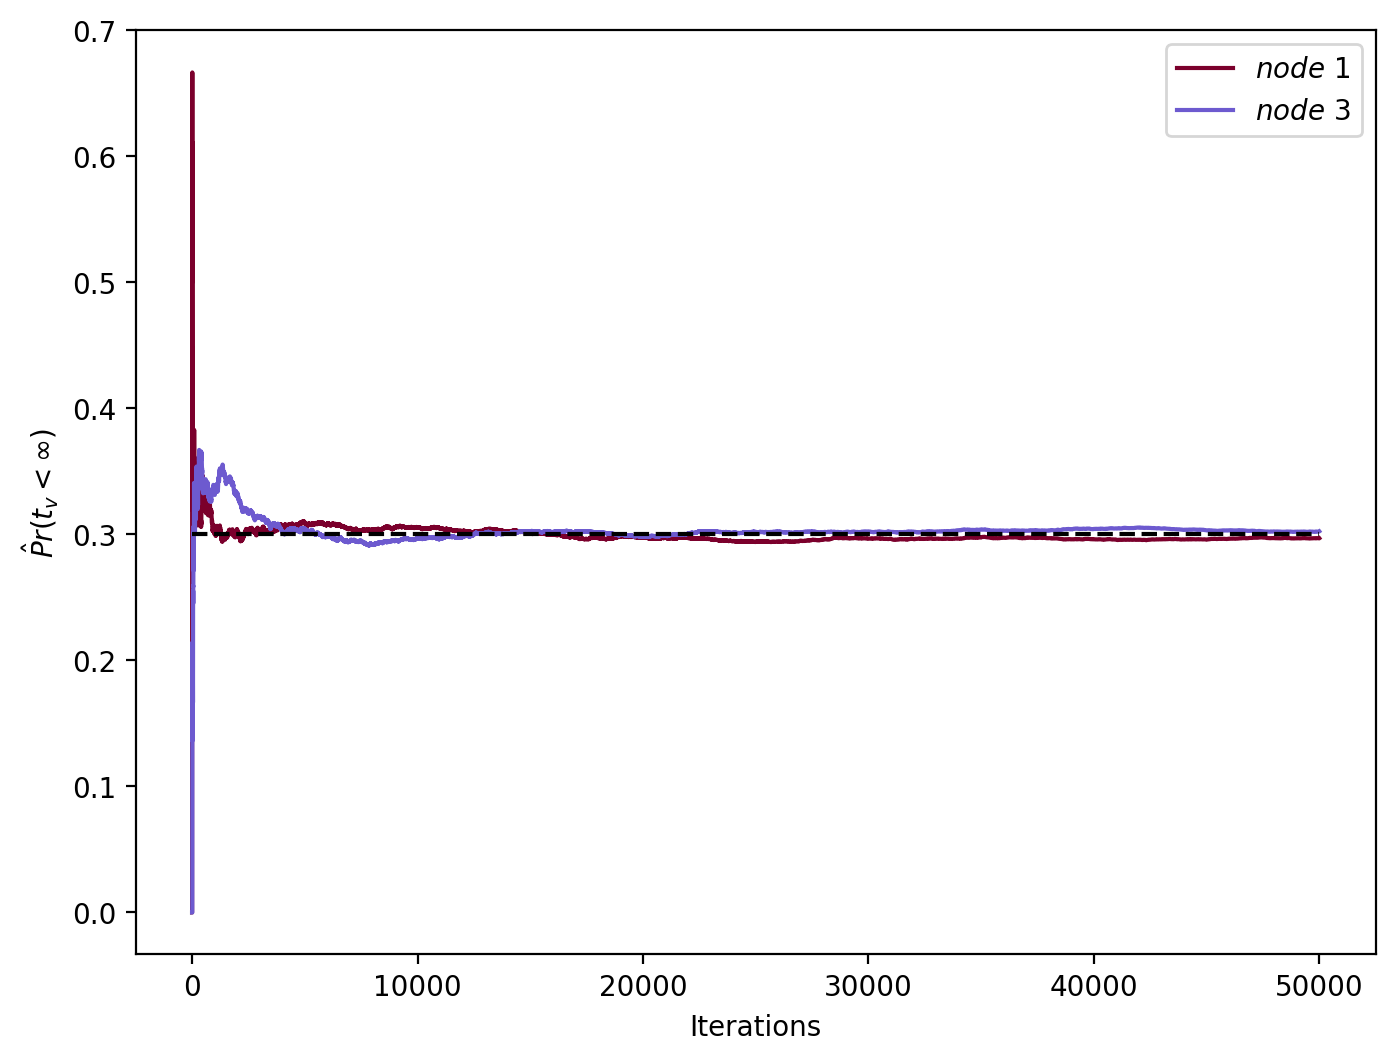

In [ ]:
figure(figsize=(8, 6), dpi=200)

plt.plot(star_node_1, label=r'$node ~ 1$', color='xkcd:bordeaux')
plt.plot(star_node_3, label=r'$node ~ 3$', color='xkcd:light indigo')
plt.hlines(y=[0.3], xmin=0, xmax=50000, colors=['black'], linestyles=['--'])
plt.ylabel(r'$\hat{P}r(I_v < \infty | D_{obs})$')
plt.xlabel('Iterations')
plt.legend()
plt.show()